In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, KFold
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from xgboost import plot_importance
import numpy as np

xgb 고른 이유 설명해두기

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [3]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [4]:
train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [5]:
train.duplicated().sum()

0

In [6]:
train['Listening_Time_minutes']

0          31.41998
1          88.01241
2          44.92531
3          46.27824
4          75.61031
            ...    
749995     56.87058
749996     45.46242
749997     15.26000
749998    100.72939
749999     11.94439
Name: Listening_Time_minutes, Length: 750000, dtype: float64

<Axes: xlabel='Listening_Time_minutes', ylabel='Count'>

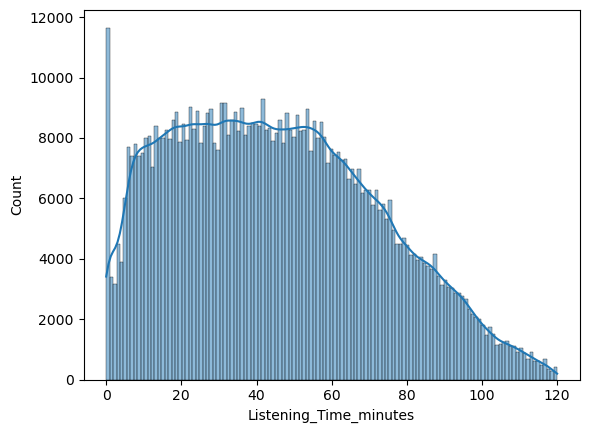

In [7]:
sns.histplot(train['Listening_Time_minutes'], kde=True)

The target is skewed distribution.

In [8]:
def checking_missing(df):
    # check missing values
    df = df.isnull().sum()
    df = df[df > 0]
    print(df)

In [9]:
checking_missing(train)
print('-'*50)
checking_missing(test)

Episode_Length_minutes          87093
Guest_Popularity_percentage    146030
Number_of_Ads                       1
dtype: int64
--------------------------------------------------
Episode_Length_minutes         28736
Guest_Popularity_percentage    48832
dtype: int64


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [11]:
train_corr = train.select_dtypes(include=['number']).corr()
train_corr

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
id,1.000000,-0.000557,0.000274,0.000637,0.000771,-0.000876
Episode_Length_minutes,-0.000557,1.000000,0.023596,-0.009704,-0.054953,0.916749
Host_Popularity_percentage,0.000274,0.023596,1.000000,0.022431,-0.017896,0.050870
Guest_Popularity_percentage,0.000637,-0.009704,0.022431,1.000000,0.007933,-0.016014
Number_of_Ads,0.000771,-0.054953,-0.017896,0.007933,1.000000,-0.118337
Listening_Time_minutes,-0.000876,0.916749,0.050870,-0.016014,-0.118337,1.000000


## handling missing Value

In [12]:
train['Episode_Sentiment'].unique()

array(['Positive', 'Negative', 'Neutral'], dtype=object)

In [13]:
train['Number_of_Ads'].unique()

array([  0.  ,   2.  ,   3.  ,   1.  ,  53.37,    nan, 103.91, 103.  ,
        53.42, 103.75,  12.  , 103.25, 103.88])

<Axes: xlabel='Number_of_Ads', ylabel='Count'>

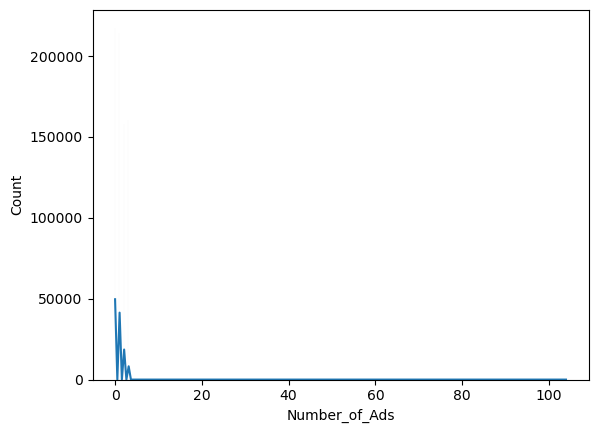

In [14]:
sns.histplot(train['Number_of_Ads'], kde=True)

### train data

In [15]:
train['Number_of_Ads'].fillna(train['Number_of_Ads'].mode().iloc[0], inplace=True)
train['Episode_Length_minutes'] = train.groupby('Genre')['Episode_Length_minutes'].transform(lambda x: x.fillna(x.median()))

<Axes: >

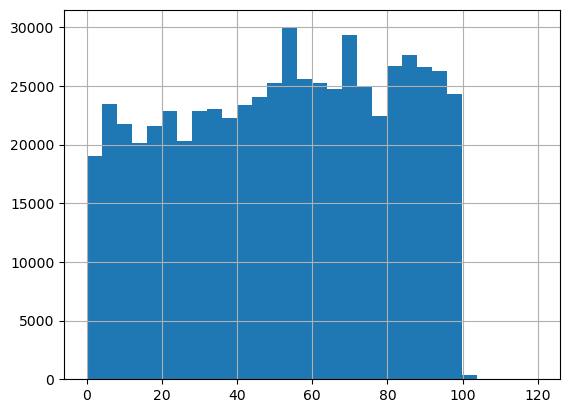

In [16]:
train['Guest_Popularity_percentage'].describe()
train['Guest_Popularity_percentage'].hist(bins=30)

In [17]:
missing_gpp = train[train['Guest_Popularity_percentage'].isna()]
missing_gpp.shape

(146030, 12)

In [18]:
missing_gpp[missing_gpp['Number_of_Ads']==0]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,63.80,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
21,21,Sports Weekly,Episode 100,67.05,Sports,58.77,Saturday,Night,NaN,0.0,Neutral,56.87222
32,32,Sound Waves,Episode 74,117.88,Music,41.28,Saturday,Morning,NaN,0.0,Positive,101.19214
52,52,Mind & Body,Episode 74,93.16,Health,81.22,Sunday,Night,NaN,0.0,Negative,70.36414
86,86,Home & Living,Episode 42,10.59,Lifestyle,66.78,Saturday,Night,NaN,0.0,Positive,7.21512
...,...,...,...,...,...,...,...,...,...,...,...,...
749958,749958,World Watch,Episode 60,69.16,News,67.67,Sunday,Morning,NaN,0.0,Negative,48.13645
749968,749968,Tech Talks,Episode 26,38.79,Technology,52.36,Wednesday,Afternoon,NaN,0.0,Neutral,16.61857
749969,749969,Business Insights,Episode 48,6.60,Business,67.54,Sunday,Afternoon,NaN,0.0,Negative,0.00000
749991,749991,Business Insights,Episode 5,62.46,Business,30.03,Tuesday,Afternoon,NaN,0.0,Positive,53.32434


- There are 146,030 missing values in Guest_Popularity_percentage (approximately 19.5% of the data).
- There is no Guest_Name column, so it’s unclear whether a guest was absent or if the information is simply missing.
- Many records with missing guest popularity still have 1 to 3 ads, making it difficult to conclude that the guest was absent.

In [19]:
#If a column has lots of missing values, filling with 0 is fine. But if the missing rate isn’t too extreme, using the genre-wise median could be a smarter option.
genre_null_ratio = train.groupby('Genre')['Guest_Popularity_percentage'].apply(lambda x: x.isna().mean())
good_genres = genre_null_ratio[genre_null_ratio < 0.5].index

mask = train['Genre'].isin(good_genres)
train.loc[mask, 'Guest_Popularity_percentage'] = train[mask].groupby('Genre')['Guest_Popularity_percentage'].transform(lambda x: x.fillna(x.median()))

train['Guest_Popularity_percentage'].fillna(0, inplace=True)

### test data

In [20]:
test['Episode_Length_minutes'] = test.groupby('Genre')['Episode_Length_minutes'].transform(lambda x: x.fillna(x.median()))

genre_null_ratio = test.groupby('Genre')['Guest_Popularity_percentage'].apply(lambda x: x.isna().mean())
good_genres = genre_null_ratio[genre_null_ratio < 0.5].index

mask = test['Genre'].isin(good_genres)
test.loc[mask, 'Guest_Popularity_percentage'] = test[mask].groupby('Genre')['Guest_Popularity_percentage'].transform(lambda x: x.fillna(x.median()))

test['Guest_Popularity_percentage'].fillna(0, inplace=True)

In [21]:
checking_missing(train)
checking_missing(test)

Series([], dtype: int64)
Series([], dtype: int64)


In [22]:
train_co = train.copy()
test_co = test.copy()

## Preprocessing 

In [23]:
train.drop(columns=['Podcast_Name', 'Episode_Title'], inplace=True)
test.drop(columns=['Podcast_Name', 'Episode_Title'], inplace=True)

In [24]:
categorical_cols = train.select_dtypes(include='object').columns
categorical_cols

Index(['Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment'], dtype='object')

In [25]:
train[categorical_cols]

,Genre,Publication_Day,Publication_Time,Episode_Sentiment
0,True Crime,Thursday,Night,Positive
1,Comedy,Saturday,Afternoon,Negative
2,Education,Tuesday,Evening,Negative
3,Technology,Monday,Morning,Positive
4,Health,Monday,Afternoon,Neutral
...,...,...,...,...
749995,Education,Saturday,Morning,Negative
749996,Business,Saturday,Night,Neutral
749997,Lifestyle,Thursday,Morning,Negative
749998,Lifestyle,Thursday,Morning,Negative


In [26]:
train.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,64.422139,59.859901,52.484351,1.348853,45.437406
std,216506.495284,30.998877,22.873098,25.539397,1.151131,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,39.420000,39.410000,34.550000,0.000000,23.178350
50%,374999.500000,63.910000,60.050000,53.400000,1.000000,43.379460
75%,562499.250000,90.310000,79.530000,71.040000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [27]:
# replace the outliers of Number_of_Ads later

In [28]:
podcast_id = test['id']
podcast_id

0         750000
1         750001
2         750002
3         750003
4         750004
           ...  
249995    999995
249996    999996
249997    999997
249998    999998
249999    999999
Name: id, Length: 250000, dtype: int64

#### Data split

In [29]:
def dataset_split(df_train, df_test):
    X = df_train.drop(['id','Listening_Time_minutes'], axis=1)
    y = train['Listening_Time_minutes']
    
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    X_test = df_test.drop('id', axis=1)
    
    return X_train, X_val, y_train, y_val, X_test

In [30]:
X_train, X_val, y_train, y_val, X_test = dataset_split(train, test)

In [31]:
numerical_cols = X_test.select_dtypes(include='number').columns.tolist()
numerical_cols

['Episode_Length_minutes',
 'Host_Popularity_percentage',
 'Guest_Popularity_percentage',
 'Number_of_Ads']

In [32]:
# create piplines for preprocessing
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # input mode instead of missing values
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)) # ordinal encoding
])

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])


In [33]:
# preprocessor = encoding + scaling
preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_pipeline, categorical_cols),
    ('num', numerical_pipeline, numerical_cols)
])

# for train
X_train_processed = preprocessor.fit_transform(X_train)

# for validation and test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [34]:
X_train_processed.shape

(600000, 8)

## Modeling

In [35]:
# create basic XGBoost Regressor
basic_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
basic_model.fit(X_train_processed, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## Evaluation

In [36]:
# evaluate data set func
def evaluate_model(model, X_val, y_val, X_train=None, y_train=None, X_test=None):
    
    # Validation set
    y_val_pred = model.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"Validation RMSE: {rmse_val:.4f}")

     # Train set (option)
    y_train_pred = None
    if X_train is not None:
        y_train_pred = model.predict(X_train)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        print(f"train RMSE: {rmse_train:.4f}")

    # Test set (option)
    y_test_pred = None
    if X_test is not None:
        y_test_pred = model.predict(X_test)

    return rmse_val, y_test_pred
        

In [37]:
rmse_val_basic, y_test_pred_basic = evaluate_model(
    basic_model,
    X_val_processed, y_val,
    X_train_processed, y_train,
    X_test_processed
)

Validation RMSE: 13.0787
train RMSE: 13.0521


### check feature importance

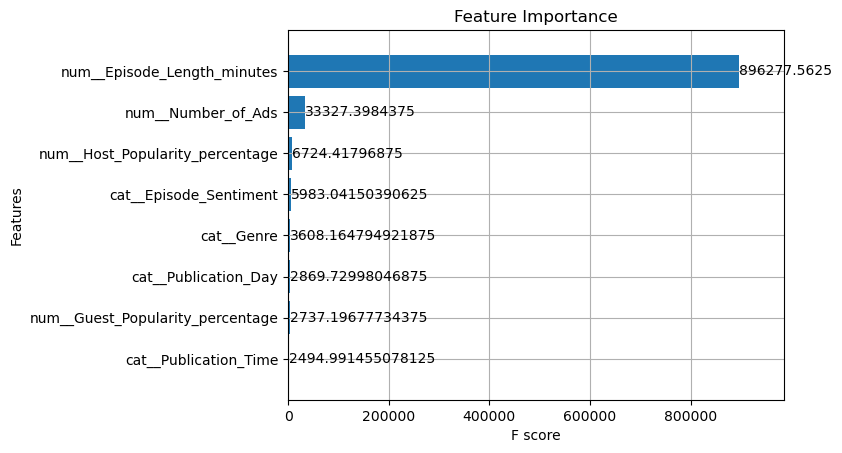

In [38]:
# booster
booster = basic_model.get_booster()

# feature name set
booster.feature_names = preprocessor.get_feature_names_out().tolist()

# plot importance
xgb.plot_importance(booster, importance_type='gain', max_num_features=10, height=0.8)
plt.title('Feature Importance')
plt.show()

# # bring importance features
# importance_dict = booster.get_score(importance_type='gain')

# # find 0 importance features
# all_features = preprocessor.get_feature_names_out()

# # importance_dict includes all except importance 0 features.
# low_importance_features = [feat for feat in all_features if feat not in importance_dict]

# print(f"Importance 0 features: {len(low_importance_features)}")
# print(low_importance_features)

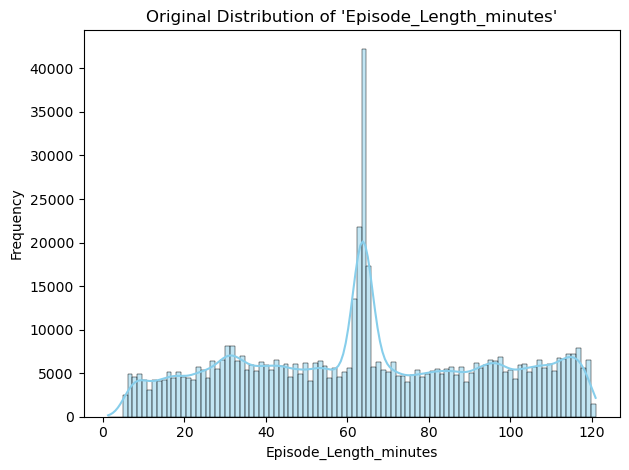

In [39]:
sns.histplot(X_train['Episode_Length_minutes'], kde=True, color='skyblue')
plt.title(f"Original Distribution of 'Episode_Length_minutes'")
plt.xlabel('Episode_Length_minutes')
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Tunning model 
#### 1. feature value log transformation

In [40]:
# X_train_log = X_train.copy()
# X_val_log = X_val.copy()
# X_test_log = X_test.copy()

# # apply log
# for df_ in [X_train_log, X_val_log, X_test_log]:
#     df_['Episode_Length_minutes_log'] = np.log1p(df_['Episode_Length_minutes'])

# # update numerical columns
# numerical_cols.append('Episode_Length_minutes_log')

# # preprocessor recreate
# preprocessor_log = ColumnTransformer(transformers=[
#     ('cat', categorical_pipeline, categorical_cols),
#     ('num', numerical_pipeline, numerical_cols)
# ])

# X_train_processed_log = preprocessor_log.fit_transform(X_train_log)
# X_val_processed_log = preprocessor_log.transform(X_val_log)
# X_test_processed_log = preprocessor_log.transform(X_test_log)

# # create log XGBoost Regressor
# log_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
# log_model.fit(X_train_processed_log, y_train)

# #evaluation
# r2_val_log, y_test_pred_log = evaluate_model(
#     log_model,
#     X_val_processed_log, y_val,
#     X_train_processed_log, y_train,
#     X_test_processed_log
# )

It seems like not worth it so, let's remove low key features.

### 2. check the low key features

#### with regularization
It also doesn't work.

In [41]:
# xgb = XGBRegressor(random_state=42, n_jobs=-1)

# param_grid = {
#     'max_depth': [4, 6],
#     'n_estimators': [100, 300],
#     'learning_rate': [0.05, 0.1],
#     # 'reg_alpha': [0, 0.1, 1],     # L1 regularization
#     # 'reg_lambda': [1, 5, 10],     # L2 regularization
#     'subsample': [0.8, 1.0],      
#     'colsample_bytree': [0.8, 1.0]
# }

# grid_xgb = GridSearchCV(xgb, param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=2)
# grid_xgb.fit(X_train_processed, y_train)

# # predict evaluation
# r2_val_xgb, y_test_pred_xgb = evaluate_model(
#     grid_xgb.best_estimator_,
#     X_val_processed, y_val,
#     X_train_processed, y_train,
#     X_test_processed
# )

### 3. Handling outliers and exploring columns for new features

In [1]:
# I made new features using Episode_Title, Podcast_Name.

In [44]:
train_co['Number_of_Ads'].value_counts()

Number_of_Ads
0.00      217593
1.00      214069
3.00      160173
2.00      158156
103.25         2
53.37          1
103.91         1
103.00         1
53.42          1
103.75         1
12.00          1
103.88         1
Name: count, dtype: int64

In [45]:
test_co['Number_of_Ads'].value_counts()

Number_of_Ads
0.00       72863
1.00       71015
3.00       53556
2.00       52564
89.12          1
2063.00        1
Name: count, dtype: int64

In the **‘Number_of_Ads’** column, any value greater than **20** is considered an outlier, as even lengthy podcast episodes are unlikely to contain that many ads. To address this, those outlier values were replaced with the mode of the column.

In [46]:
mode_ads = train_co['Number_of_Ads'].mode()[0]
train_co.loc[train_co['Number_of_Ads'] > 20, 'Number_of_Ads'] = mode_ads

mode_ads_test = test_co['Number_of_Ads'].mode()[0]
test_co.loc[test_co['Number_of_Ads'] > 20, 'Number_of_Ads'] = mode_ads_test

In [47]:
train_co.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment', 'Listening_Time_minutes'],
      dtype='object')

In [48]:
train_co['Podcast_Name'].unique()

array(['Mystery Matters', 'Joke Junction', 'Study Sessions',
       'Digital Digest', 'Mind & Body', 'Fitness First', 'Criminal Minds',
       'News Roundup', 'Daily Digest', 'Music Matters', 'Sports Central',
       'Melody Mix', 'Game Day', 'Gadget Geek', 'Global News',
       'Tech Talks', 'Sport Spot', 'Funny Folks', 'Sports Weekly',
       'Business Briefs', 'Tech Trends', 'Innovators', 'Health Hour',
       'Comedy Corner', 'Sound Waves', 'Brain Boost', "Athlete's Arena",
       'Wellness Wave', 'Style Guide', 'World Watch', 'Humor Hub',
       'Money Matters', 'Healthy Living', 'Home & Living',
       'Educational Nuggets', 'Market Masters', 'Learning Lab',
       'Lifestyle Lounge', 'Crime Chronicles', 'Detective Diaries',
       'Life Lessons', 'Current Affairs', 'Finance Focus', 'Laugh Line',
       'True Crime Stories', 'Business Insights', 'Fashion Forward',
       'Tune Time'], dtype=object)

In [49]:
train_co['Genre'].unique()

array(['True Crime', 'Comedy', 'Education', 'Technology', 'Health',
       'News', 'Music', 'Sports', 'Business', 'Lifestyle'], dtype=object)

To create **"Episode_Number"**, I extracted just the episode number from the ‘Episode_Title’ column, as the title often includes the episode’s order in the series.

In [50]:
train_co['Episode_Number'] = train_co['Episode_Title'].str.extract(r'(\d+)').astype(int)
test_co['Episode_Number'] = test_co['Episode_Title'].str.extract(r'(\d+)').astype(int)

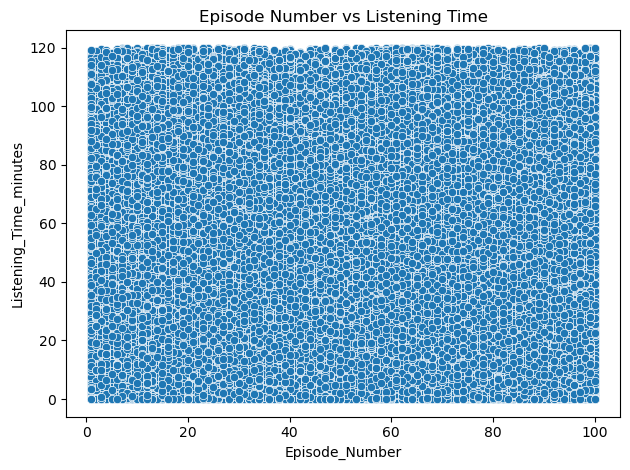

In [51]:
sns.scatterplot(data=train_co, x='Episode_Number', y='Listening_Time_minutes')
plt.title("Episode Number vs Listening Time")
plt.tight_layout()
plt.show()

This column isn't related with target.

It occurred to me that **listening time** might vary across **episode numbers depending on the podcast name**, so I explored this possibility.

/var/folders/8f/1rdz8t2n26s309qzylpj9crw0000gn/T/ipykernel_90566/1492608610.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


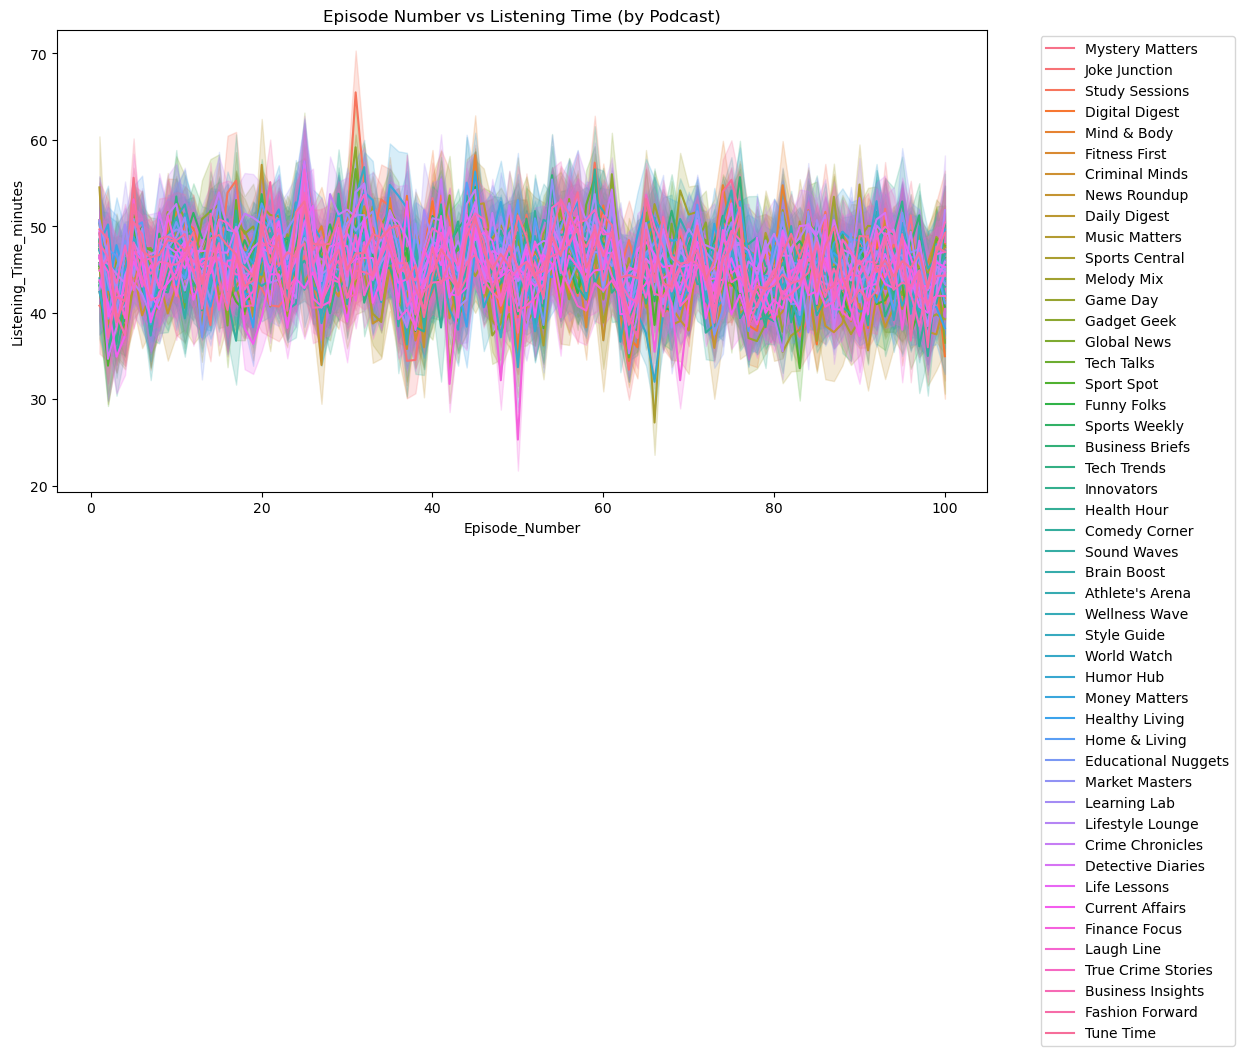

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=train_co, x='Episode_Number', y='Listening_Time_minutes', hue='Podcast_Name', estimator='mean')
plt.title('Episode Number vs Listening Time (by Podcast)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

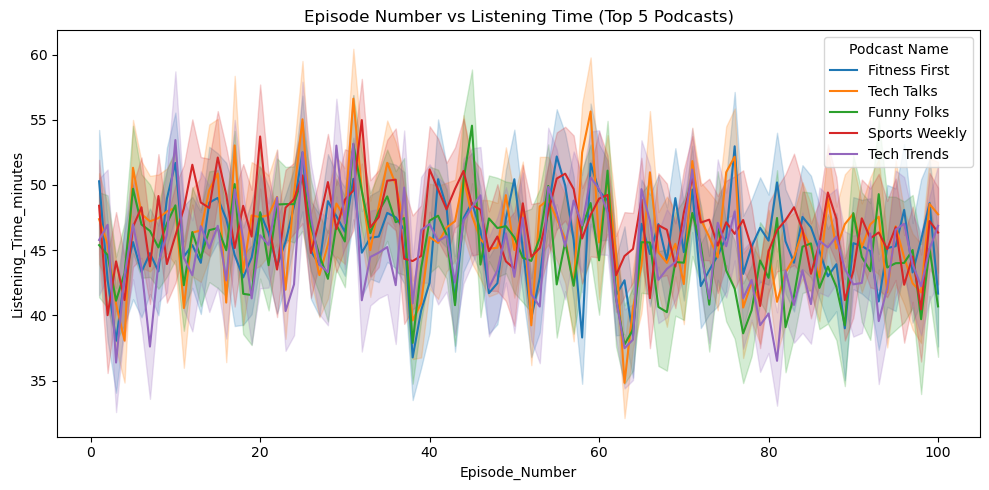

In [54]:
# Listening Time by Episode Number for Top Podcasts
top_podcasts = train_co['Podcast_Name'].value_counts().head(5).index
filtered = train_co[train_co['Podcast_Name'].isin(top_podcasts)]

plt.figure(figsize=(10, 5))
sns.lineplot(data=filtered, x='Episode_Number', y='Listening_Time_minutes', hue='Podcast_Name', estimator='mean')
plt.title('Episode Number vs Listening Time (Top 5 Podcasts)')
plt.legend(title='Podcast Name')
plt.tight_layout()
plt.show()

While there are slight variations, there’s **no consistent upward or downward trend** in listening time as episode numbers progress.

### 4. making new feature

Idea: Summarize the episode trend for each podcast as a single numerical feature.

For example, I can calculate the **slope** of the relationship between **Episode Number and Listening Time for each podcast**. This slope can then be used as a podcast-level feature.

In our case, we want to quantify **how Listening Time changes as episode numbers increase for each Podcast_Name**. To ensure that we avoid data leakage when calculating this slope per podcast.

- I compute the slope only using the training data, and for the test set, I simply lookup the precomputed value without touching the test targets.

* We use K-Fold cross-validation within the training set, so that the slope for each row is computed without using its own target value.
  -> to prevent data leakage and overfitting

In [55]:
# split data to 5
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(train_co):
    fold_train = train_co.iloc[train_idx]  # train data 
    fold_val = train_co.iloc[val_idx]      # val data
    
    trend_dict = {} # based on fold_train
    for name, group in fold_train.groupby('Podcast_Name'):
        if group['Episode_Number'].nunique() > 1:
            # if the podcast has episodes than 1 we can find a slope
            # polyfit : caculate slope
            slope = np.polyfit(group['Episode_Number'], group['Listening_Time_minutes'], 1)[0] # when episode 1 increase
            trend_dict[name] = slope
        else:
            trend_dict[name] = 0
            
    # mapping slope to valid data
    train_co.loc[train_co.index[val_idx], 'Podcast_Trend_Slope'] = fold_val['Podcast_Name'].map(trend_dict).fillna(0)

for test data set

In [56]:
# mapping slopes which are values using all train data 
final_trend_dict = {} # based on train data
for name, group in train_co.groupby('Podcast_Name'):
    if group['Episode_Number'].nunique() > 1:
        # if the podcast has episodes than 1 we can find a slope
        # polyfit : caculate slope
        slope = np.polyfit(group['Episode_Number'], group['Listening_Time_minutes'], 1)[0] # when episode 1 increase
        final_trend_dict[name] = slope
    else:
        final_trend_dict[name] = 0 

# mapping slope to test data
test_co['Podcast_Trend_Slope'] = test_co['Podcast_Name'].map(final_trend_dict).fillna(0)

In [57]:
print(train_co['Podcast_Trend_Slope'].isna().sum())
print(test_co['Podcast_Trend_Slope'].isna().sum())

0
0


In [58]:
train_co.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes,Episode_Number,Podcast_Trend_Slope
0,0,Mystery Matters,Episode 98,63.80,True Crime,74.81,Thursday,Night,54.19,0.0,Positive,31.41998,98,-0.014248
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241,26,-0.009053
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531,16,-0.021676
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824,45,-0.039503
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031,86,0.005836


In [59]:
test_co.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Episode_Number,Podcast_Trend_Slope
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral,73,-0.028421
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,53.27,0.0,Neutral,23,-0.012602
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive,11,-0.007367
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive,73,-0.011170
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral,50,-0.010368


In [60]:
train_co.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       750000 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  750000 non-null  float64
 9   Number_of_Ads                750000 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
 12  Episode_Number               750000 non-null  int64  
 13 

<Axes: xlabel='Episode_Length_minutes', ylabel='Count'>

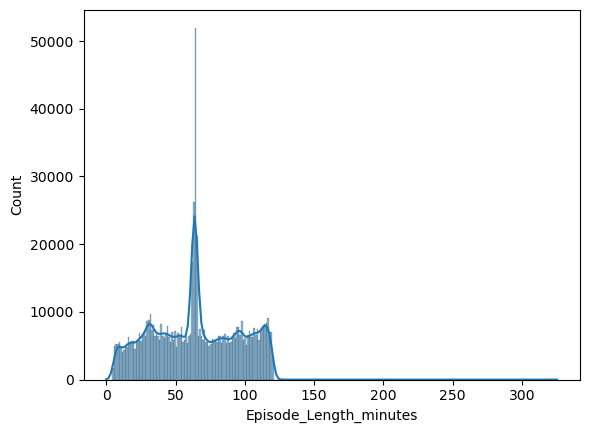

In [61]:
sns.histplot(train_co['Episode_Length_minutes'], kde=True)

When the **episode length** increases, the **listening time** tends to **increase** as well.

Based on the observed trend that longer episodes generally lead to higher listening time,

* I created two new features to better capture this relationship:
1. **Is_Long_Episode** : a binary feature indicating whether the episode is longer than 60 minutes. This helps the model distinguish between short and long-form content.
2.	**Ad_Ratio** : the number of ads divided by the total episode length, representing the density of advertisements. This feature is designed to measure how frequently ads occur relative to the episode duration, which may influence listener engagement.

In [63]:
# new binary column 
train_co['Is_Long_Episode'] = (train_co['Episode_Length_minutes'] > 60).astype(int)
test_co['Is_Long_Episode'] = (test_co['Episode_Length_minutes'] > 60).astype(int)

In [64]:
# new column - how many ads in episode by length
train_co['Ad_Ratio'] = train_co['Number_of_Ads'] / train_co['Episode_Length_minutes']
test_co['Ad_Ratio'] = test_co['Number_of_Ads'] / test_co['Episode_Length_minutes']

In [65]:
test_co['Ad_Ratio'].describe()

count    250000.000000
mean          0.033088
std           0.051192
min           0.000000
25%           0.000000
50%           0.018963
75%           0.040433
max           0.847458
Name: Ad_Ratio, dtype: float64

### Preprocessing + encoding + data split

In [66]:
train_co.drop(columns=['Podcast_Name', 'Episode_Title'], inplace=True)
test_co.drop(columns=['Podcast_Name', 'Episode_Title'], inplace=True)

categorical_cols = train_co.select_dtypes(include='object').columns.tolist()

podcast_id = test['id']

X_train, X_val, y_train, y_val, X_test = dataset_split(train_co, test_co)

numerical_cols = X_test.select_dtypes(include='number').columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'Is_Long_Episode'] # except boolean

# preprocessor = encoding + scaling
preprocessor_xgb = ColumnTransformer(transformers=[
    ('cat', categorical_pipeline, categorical_cols),
    ('num', StandardScaler(), numerical_cols), # 
    ('binary', 'passthrough', ['Is_Long_Episode']) # don't need to encode with binary type
])

# for train
X_train_processed_nf = preprocessor_xgb.fit_transform(X_train)

# for validation and test
X_val_processed_nf = preprocessor_xgb.transform(X_val)
X_test_processed_nf = preprocessor_xgb.transform(X_test)

In [67]:
# create basic XGBoost Regressor
xgb_nf_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_nf_model.fit(X_train_processed_nf, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

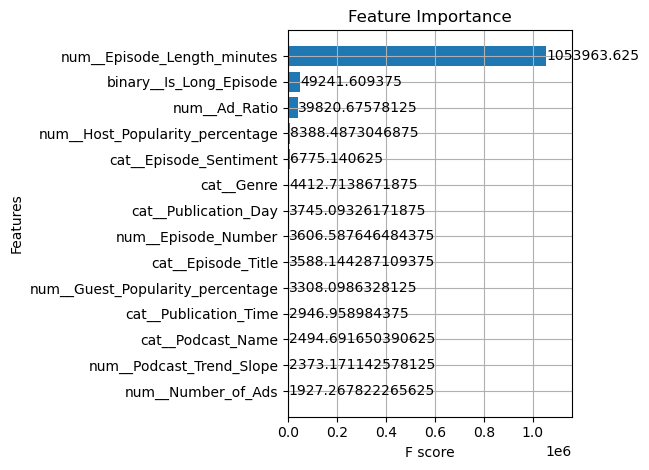

In [69]:
# for checking feature importance
booster = xgb_nf_model.get_booster() # booster : object
booster.feature_names = preprocessor_xgb.get_feature_names_out().tolist() # mapping the colums name
plot_importance(xgb_nf_model, importance_type='gain', max_num_features=len(booster.feature_names), height=0.8)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [70]:
rmse_val_nf, y_test_pred_nf = evaluate_model(
    xgb_nf_model,
    X_val_processed_nf, y_val,
    X_train_processed_nf, y_train,
    X_test_processed_nf
)

Validation RMSE: 13.0594
train RMSE: 13.0148


In [74]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)

param_grid = {
'max_depth': [3, 4, 5], # control modeling
'n_estimators': [100, 300, 500], # how many trees are we gonna use
'learning_rate': [0.01, 0.05, 0.1], # evaluation and speed
'subsample': [0.8, 1.0], # some of data
'colsample_bytree': [0.8, 1.0], # use some of features
'reg_alpha': [0, 0.1, 1], # L1 regularization
'reg_lambda': [5] # L2 regularization
}

grid_xgb = GridSearchCV(xgb, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2)
grid_xgb.fit(X_train_processed_nf, y_train)

# predict evaluation
rmse_val_xgb, rmse_test_pred_xgb = evaluate_model(
    grid_xgb.best_estimator_,
    X_val_processed_nf, y_val,
    X_train_processed_nf, y_train,
    X_test_processed_nf
)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Validation RMSE: 13.0170
train RMSE: 12.8813


In [72]:
submission = pd.DataFrame({
    'id': podcast_id,  # id
    'Listening_Time_minutes': rmse_test_pred_xgb
})

submission.to_csv('submission_xgb_nf.csv', index=False)

### Episode_Length_minutes tranform log
Episode_Length_minutes has the wide and skewed distribution. I applied a log method for helping to reduce the impact of extreme values and normalize the distribution.
However, I couldn't see imporving moment with model.

In [ ]:
# X_train_log = X_train.copy()
# X_val_log = X_val.copy()
# X_test_log = X_test.copy()

# for df in [X_train_log, X_val_log, X_test_log]:
#     df['Episode_Length_minutes_log'] = np.log1p(df['Episode_Length_minutes'])

# numerical_cols_log = [col for col in numerical_cols if col != 'Episode_Length_minutes']
# numerical_cols_log.append('Episode_Length_minutes_log')

# preprocessor_log = ColumnTransformer(transformers=[
#     ('cat', categorical_pipeline, categorical_cols),
#     ('num', StandardScaler(), numerical_cols_log)
# ])

# X_train_processed_log = preprocessor_log.fit_transform(X_train_log)
# X_val_processed_log = preprocessor_log.transform(X_val_log)
# X_test_processed_log = preprocessor_log.transform(X_test_log)

# grid_xgb.fit(X_train_processed_log, y_train)

# # predict evaluation
# rmse_val_log, rmse_test_pred_log = evaluate_model(
#     grid_xgb.best_estimator_,
#     X_val_processed_log, y_val,
#     X_train_processed_log, y_train,
#     X_test_processed_log
# )

## Conclusion

The final XGBoost model demonstrated **stable and generalizable performance**,  
with a validation RMSE of **13.0170** and a training RMSE of **12.8813**,  
indicating minimal overfitting.

**Feature importance analysis** showed that:

- `Episode_Length_minutes` was by far the most influential feature,  
  confirming its critical role in predicting listening time.
- Engineered features such as `Is_Long_Episode` and `Ad_Ratio` ranked 2nd and 3rd respectively,  
  highlighting the value of custom features based on content structure.
- Categorical variables like `Genre`, `Episode_Sentiment`, and `Publication_Day` had moderate impact.
- `Podcast_Trend_Slope`, designed to capture episode-level trends, had lower importance in this model.
- Features like `Number_of_Ads` and `Podcast_Name` contributed minimally,  
  possibly due to redundancy with other variables.

In summary, the model emphasizes that **episode duration and ad density are key drivers** of listening behavior.